In [1]:
#234567890#234567890#234567890#234567890#234567890#234567890#234567890#234567890
import torch
import torch.nn as nn
import torch.optim as optim

import helper_utils as u

torch.manual_seed(42)

In [2]:
dists = torch.tensor([[1.], [2.], [3.], [4.]], dtype=torch.float32)
times = torch.tensor([[6.96], [12.11], [16.77], [22.21]], dtype=torch.float32)

In [3]:
mod = nn.Sequential(nn.Linear(1, 1))  # time = b + w*dist

In [4]:
loss_func = nn.MSELoss()
opt = optim.SGD(mod.parameters(), lr=0.01)

In [5]:
for epoch in range(500):
    opt.zero_grad()
    preds = mod(dists)
    loss = loss_func(preds, times)
    loss.backward()
    opt.step()
    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch + 1}: Loss: {loss.item():.6f}')

Epoch 50: Loss: 0.039449
Epoch 100: Loss: 0.035812
Epoch 150: Loss: 0.033119
Epoch 200: Loss: 0.031124
Epoch 250: Loss: 0.029646
Epoch 300: Loss: 0.028550
Epoch 350: Loss: 0.027739
Epoch 400: Loss: 0.027137
Epoch 450: Loss: 0.026692
Epoch 500: Loss: 0.026361


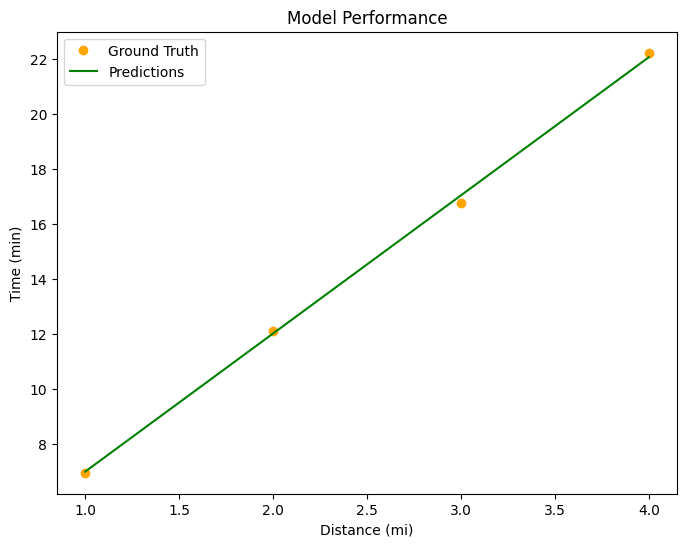

In [6]:
u.plot_results(mod, dists, times)

**Question:** Can you make a 7-mile delivery in ≤ 30min?

In [7]:
d = 7.

with torch.no_grad():
    new_d = torch.tensor([[d]], dtype=torch.float32)
    pred = mod(new_d)
    print(f'Predicted time: {pred.item():.2f} minutes')
    if pred > 30:
        print('Don\'t do it unless you can really haul ass!')
    else:
        pritn('You can do it!')

Predicted time: 37.09 minutes
Don't do it unless you can really haul ass!


In [12]:
layer = mod[0]
w = layer.weight.data.numpy()[0][0]
b = layer.bias.data.numpy()[0]
print(f'Mod: time = {w:.4f}dist + {b:.4f}')

Mod: time = 5.0155dist + 1.9850


In [13]:
# Combined dataset: bikes for short distances, cars for longer ones
new_distances = torch.tensor(
    [[1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
     [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
     [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], 
     [15.5], [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5],
     [20.0]], 
    dtype=torch.float32)

# Corresponding delivery times in minutes
new_times = torch.tensor(
    [[6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], 
     [37.15], [42.35], [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], 
     [69.45], [71.57], [72.8], [73.88], [76.34], [76.38], [78.34], [80.07], 
     [81.86], [84.45], [83.98], [86.55], [88.33], [86.83], [89.24], [88.11], 
     [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]], 
    dtype=torch.float32)

In [14]:
with torch.no_grad():
    preds = mod(new_distances)

In [16]:
new_loss = loss_func(preds, new_times)
new_loss

tensor(179.2567)

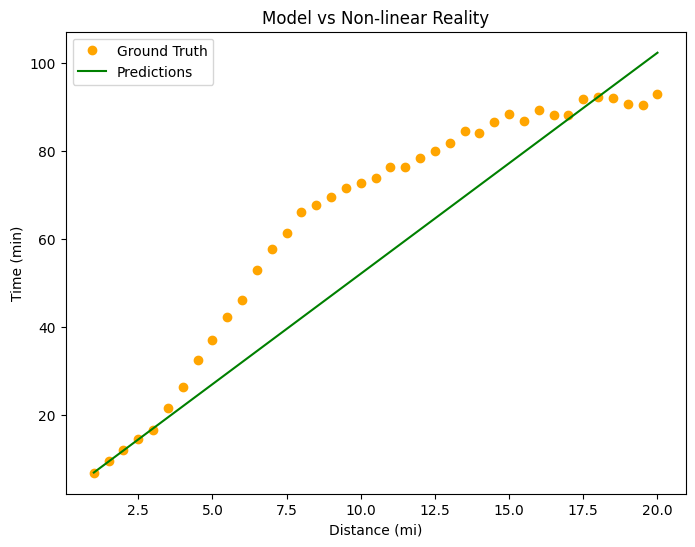

In [17]:
u.plot_nonlinear_comparison(mod, new_distances, new_times)